# Elastodynamics and modal analysis

![](elastodynamics-light.webp)
![](elastodynamics-dark.webp)

*Figure 1*: Free vibration of the cantilever beam after the static tip load is released
at $t = 0$, colored by the deflection magnitude (displacements exaggerated by a factor
of 75). The animation covers three periods of the first bending mode.

## Introduction

This tutorial is a follow-up to the linear elasticity tutorial
where we take the step from statics to dynamics: instead of asking *how much* a structure
deforms under a load, we ask *how it moves* — at which frequencies it prefers to vibrate,
and how it responds over time when a load is suddenly removed.

Concretely, we compute the natural frequencies and vibration modes of a cantilever beam
(*modal analysis*), and then simulate its free vibration after releasing a static tip load,
using Newmark time integration. Since a slender cantilever is a classic textbook problem,
we can verify both parts against analytical Euler-Bernoulli beam theory.

This tutorial teaches the following new concepts on top of the linear elasticity tutorial:
- Assembly of the (consistent) **mass matrix**
- Solving the **generalized eigenvalue problem** for natural frequencies and mode shapes
- **Rayleigh damping**
- Implicit time integration of second order systems with the **Newmark method**

### Strong and semi-discrete form

The balance of momentum, now including the inertia term, reads
$$
\mathrm{div}(\boldsymbol{\sigma}) + \boldsymbol{b} = \rho \ddot{\boldsymbol{u}}
\quad \boldsymbol{x} \in \Omega
$$
where $\rho$ is the density and $\ddot{\boldsymbol{u}}$ the acceleration. As before we use
linear isotropic elasticity, $\boldsymbol{\sigma} = \mathsf{C} : \boldsymbol{\varepsilon}$,
and neglect body forces. Multiplying with a test function $\delta\boldsymbol{u}$ and
integrating by parts gives the weak form: find $\boldsymbol{u} \in \mathbb{U}$ such that
$$
\int_\Omega \delta\boldsymbol{u} \cdot \rho \ddot{\boldsymbol{u}}\, \mathrm{d}\Omega
+ \int_\Omega \mathrm{grad}(\delta\boldsymbol{u}) : \boldsymbol{\sigma}\, \mathrm{d}\Omega
= \int_\Gamma \delta\boldsymbol{u} \cdot \boldsymbol{t}\, \mathrm{d}\Gamma
\quad \forall\, \delta\boldsymbol{u} \in \mathbb{T}.
$$
Introducing the finite element approximation
$\boldsymbol{u} \approx \boldsymbol{N}_j \hat{u}_j(t)$ (note that the nodal values now
depend on time while the shape functions depend on space only) yields the semi-discrete
equation of motion
$$
M_{ij} \ddot{\hat{u}}_j + K_{ij} \hat{u}_j = f_i^\mathrm{ext}
$$
with the stiffness matrix $K_{ij}$ known from the linear elasticity tutorial, and the
(consistent) mass matrix
$$
M_{ij} = \int_\Omega \rho\, \boldsymbol{N}_i \cdot \boldsymbol{N}_j\, \mathrm{d}\Omega .
$$
In practice one often adds a damping term $C_{ij} \dot{\hat{u}}_j$ to the left hand side.
Since damping is difficult to characterize from first principles, a common pragmatic
choice is *Rayleigh damping*,
$$
\underline{\underline{C}} = \alpha \underline{\underline{M}} + \beta \underline{\underline{K}},
$$
which we will use in the second part of this tutorial. The semi-discrete equation of
motion including damping then reads
$$
M_{ij} \ddot{\hat{u}}_j + C_{ij} \dot{\hat{u}}_j + K_{ij} \hat{u}_j = f_i^\mathrm{ext}.
$$

### Modal analysis

Assuming free ($f^\mathrm{ext} = 0$), undamped vibration with the harmonic ansatz
$\hat{u}_j(t) = \phi_j \sin(\omega t)$, the equation of motion reduces to the
generalized eigenvalue problem
$$
K_{ij} \phi_j = \omega^2 M_{ij} \phi_j
$$
where the eigenvalues $\omega^2$ are the squares of the angular natural frequencies, and
the eigenvectors $\phi_j$ are the corresponding vibration modes.

For a slender cantilever beam, Euler-Bernoulli beam theory provides the analytical
natural frequencies
$$
f_n = \frac{(\beta_n L)^2}{2\pi L^2} \sqrt{\frac{EI}{\rho A}}
$$
where $(\beta_n L)^2 \in \{3.5160, 22.0345, 61.6972, 120.0902, \ldots\}$ for the first bending
modes, $A$ is the cross section area and $I$ the area moment of inertia about the bending
axis (see e.g. the [cantilevered beam example on
Wikipedia](https://en.wikipedia.org/wiki/Euler%E2%80%93Bernoulli_beam_theory#Example:_Cantilevered_beam)).
We will use these as reference values.

### Newmark time integration

For the transient simulation we discretize in time with the
[Newmark method](https://en.wikipedia.org/wiki/Newmark-beta_method): given the
solution $(\underline{u}_n, \underline{v}_n, \underline{a}_n)$ at time $t_n$
(displacement, velocity and acceleration), the update to $t_{n+1} = t_n + \Delta t$ is
$$
\begin{align*}
\underline{u}_{n+1} &= \underline{u}_n + \Delta t\, \underline{v}_n
  + \Delta t^2 \left[\left(\tfrac{1}{2} - \beta_\mathrm{N}\right) \underline{a}_n + \beta_\mathrm{N}\, \underline{a}_{n+1}\right] \\
\underline{v}_{n+1} &= \underline{v}_n
  + \Delta t \left[(1 - \gamma_\mathrm{N})\, \underline{a}_n + \gamma_\mathrm{N}\, \underline{a}_{n+1}\right]
\end{align*}
$$
where the new acceleration $\underline{a}_{n+1}$ is found by inserting these expressions
into the equation of motion at $t_{n+1}$,
$$
\left[\underline{\underline{M}} + \gamma_\mathrm{N} \Delta t\, \underline{\underline{C}}
+ \beta_\mathrm{N} \Delta t^2\, \underline{\underline{K}}\right] \underline{a}_{n+1}
= \underline{f}_{n+1}
- \underline{\underline{C}}\, \underline{\tilde{v}}_{n+1}
- \underline{\underline{K}}\, \underline{\tilde{u}}_{n+1}
$$
with the predictors
$\underline{\tilde{u}}_{n+1} = \underline{u}_n + \Delta t\, \underline{v}_n + (\tfrac{1}{2} - \beta_\mathrm{N}) \Delta t^2\, \underline{a}_n$
and
$\underline{\tilde{v}}_{n+1} = \underline{v}_n + (1 - \gamma_\mathrm{N}) \Delta t\, \underline{a}_n$.
We use the parameters $\beta_\mathrm{N} = 1/4$ and $\gamma_\mathrm{N} = 1/2$ ("average
acceleration"), for which the method is unconditionally stable and second order
accurate. Note that the matrix on the left hand side, the *effective mass
matrix*
$$
\underline{\underline{M}}_\mathrm{eff} = \underline{\underline{M}}
+ \gamma_\mathrm{N} \Delta t\, \underline{\underline{C}}
+ \beta_\mathrm{N} \Delta t^2\, \underline{\underline{K}},
$$
is constant, so it can be factorized once before the time stepping loop. Since we solve
the equation of motion for the acceleration $\underline{a}_{n+1}$ this is the
*acceleration form* of the Newmark method; textbooks also commonly present the
equivalent displacement form, where the update expressions are instead inserted into the
equation of motion such that an effective *stiffness* system is solved for
$\underline{u}_{n+1}$.

## Implementation

First we load the packages we need: KrylovKit provides the iterative eigenvalue solver,
and WriteVTK the `paraview_collection` used to write time series output.

In [1]:
using Ferrite, SparseArrays, LinearAlgebra
using KrylovKit, WriteVTK
import Plots

### Geometry and discretization
We consider a slender steel cantilever, 1 m long with a rectangular 50 mm × 10 mm cross
section, clamped at $x = 0$. Since the geometry is a box we can use `generate_grid`
directly. All quantities are in SI units (m, kg, s, Pa).

In [2]:
L = 1.0    # beam length in x [m]
w = 0.05   # width in y [m]
h = 0.01   # thickness in z [m]
grid = generate_grid(Hexahedron, (60, 4, 2), zero(Vec{3}), Vec(L, w, h));

Low order elements behave overly stiff in bending ("shear locking"), which would
significantly overestimate the natural frequencies on this coarse mesh. We therefore use
quadratic Lagrange interpolation for the displacement field, while the geometry
(which is exactly represented by the trilinear hexahedra) keeps its linear interpolation.
When choosing the quadrature rule the mass matrix needs to be kept in mind: since its
integrand $\rho\, \boldsymbol{N}_i \cdot \boldsymbol{N}_j$ contains the product of two
shape function *values* it is of higher polynomial degree (4 per direction for the
quadratic interpolation) than the typical stiffness terms containing gradients, and a
Gauss rule with three points per direction (exact through degree 5) is required to
integrate it exactly on the affine cells used here.

In [3]:
ip = Lagrange{RefHexahedron, 2}()^3
ip_geo = Lagrange{RefHexahedron, 1}()
qr = QuadratureRule{RefHexahedron}(3)
cellvalues = CellValues(qr, ip, ip_geo);

Distribute the degrees of freedom, and clamp all displacement components on the left
facet set.

In [4]:
dh = DofHandler(grid)
add!(dh, :u, ip)
close!(dh)

ch = ConstraintHandler(dh)
add!(ch, Dirichlet(:u, getfacetset(grid, "left"), (x, t) -> zero(Vec{3})))
close!(ch);

### Material
We use the same isotropic linear elasticity as in the linear elasticity tutorial (but in
3d, and with parameters for steel), and additionally define the density.

In [5]:
Emod = 210.0e9 # Young's modulus [Pa]
ν = 0.3        # Poisson's ratio [-]
ρ = 7850.0     # density [kg/m³]

Gmod = Emod / (2 * (1 + ν))  # Shear modulus
Kmod = Emod / (3 * (1 - 2ν)) # Bulk modulus

C = gradient(ϵ -> 2 * Gmod * dev(ϵ) + 3 * Kmod * vol(ϵ), zero(SymmetricTensor{2, 3}));

### Assembly of the stiffness and mass matrices
The element routine computes the element stiffness matrix `ke` and the element mass
matrix `me` in the same quadrature loop. Compared to the linear elasticity tutorial, the
only new ingredient is the term `ρ * (Nᵢ ⋅ Nⱼ)` where `Nᵢ` and `Nⱼ` are the (vector
valued) shape function *values* rather than their gradients.

In [6]:
function assemble_cell!(ke, me, cellvalues, C, ρ)
    for q_point in 1:getnquadpoints(cellvalues)
        dΩ = getdetJdV(cellvalues, q_point)
        for i in 1:getnbasefunctions(cellvalues)
            Nᵢ = shape_value(cellvalues, q_point, i)
            ∇Nᵢ = shape_gradient(cellvalues, q_point, i)
            for j in 1:getnbasefunctions(cellvalues)
                Nⱼ = shape_value(cellvalues, q_point, j)
                ∇ˢʸᵐNⱼ = shape_symmetric_gradient(cellvalues, q_point, j)
                ke[i, j] += (∇Nᵢ ⊡ C ⊡ ∇ˢʸᵐNⱼ) * dΩ
                me[i, j] += ρ * (Nᵢ ⋅ Nⱼ) * dΩ
            end
        end
    end
    return
end

assemble_cell! (generic function with 1 method)

The global assembly loops over all cells and assembles into both global matrices, using
one assembler for each.

In [7]:
function assemble_global!(K, M, dh, cellvalues, C, ρ)
    n_basefuncs = getnbasefunctions(cellvalues)
    ke = zeros(n_basefuncs, n_basefuncs)
    me = zeros(n_basefuncs, n_basefuncs)
    K_assembler = start_assemble(K)
    M_assembler = start_assemble(M)
    for cell in CellIterator(dh)
        reinit!(cellvalues, cell)
        fill!(ke, 0.0)
        fill!(me, 0.0)
        assemble_cell!(ke, me, cellvalues, C, ρ)
        assemble!(K_assembler, celldofs(cell), ke)
        assemble!(M_assembler, celldofs(cell), me)
    end
    return
end

K = allocate_matrix(dh)
M = allocate_matrix(dh)
assemble_global!(K, M, dh, cellvalues, C, ρ);

### Part 1: Modal analysis

To solve the eigenvalue problem we restrict the matrices to the *free* degrees of
freedom, i.e. we simply delete the rows and columns belonging to the constrained
(clamped) dofs.

> **Why not `apply!` here?**
>
> For linear systems we usually enforce Dirichlet conditions with `apply!`,
> which zeroes the constrained rows and columns and assigns a representative diagonal
> value. Applying it separately to both `K` and `M` would retain the constrained dofs
> and introduce one artificial eigenpair per constrained dof. These artificial
> eigenpairs have $\omega^2 = \bar{k} / \bar{m}$, where $\bar{k}$ and $\bar{m}$ are
> the diagonal values inserted into `K` and `M`; depending on the problem and mesh,
> they can contaminate the part of the spectrum of interest. Restricting the matrices
> to the free dofs avoids these nonphysical modes altogether.

In [8]:
fdofs = free_dofs(ch)
Kf = K[fdofs, fdofs]
Mf = M[fdofs, fdofs];

We want the *smallest* eigenvalues of $K \phi = \omega^2 M \phi$, since the lowest
frequencies dominate the structural response. Iterative eigensolvers however converge to
the eigenvalues of *largest* magnitude. The standard remedy is the *shift-and-invert*
trick: the operator $K^{-1} M$ has eigenvalues $1 / \omega^2$, so its largest eigenvalues
correspond exactly to the smallest natural frequencies. Since `Kf` is symmetric positive
definite (rigid body motion is prevented by the clamping) we can factorize it once with a
Cholesky factorization, and hand the operator to KrylovKit as a plain function.

In [9]:
nev = 6 # number of modes to compute
Kfact = cholesky(Symmetric(Kf))
vals, vecs, info = eigsolve(x -> Kfact \ (Mf * x), length(fdofs), nev, :LM; krylovdim = 40)
info.converged >= nev || error("eigensolver did not converge");

Back-transforming the eigenvalues gives the natural frequencies in Hz:

In [10]:
ω² = [1 / real(v) for v in vals[1:nev]]
freqs = sqrt.(ω²) ./ (2π)

6-element Vector{Float64}:
   8.383449695226473
  41.75733103061509
  52.51501968867299
 146.97073707851644
 258.704433859869
 287.8267186317733

Let us compare with the Euler-Bernoulli beam theory predictions. Bending about the weak
axis (deflection in the thickness direction $z$) uses $I = w h^3 / 12$, and about the
strong axis (deflection in $y$) $I = h w^3 / 12$:

In [11]:
function analytical_frequencies(EI, m, L, n)
    βL² = (3.51602, 22.0345, 61.6972, 120.0902)
    return [βL²[i] / (2π * L^2) * sqrt(EI / m) for i in 1:n]
end
A = w * h
f_weak = analytical_frequencies(Emod * w * h^3 / 12, ρ * A, L, 4)
f_strong = analytical_frequencies(Emod * h * w^3 / 12, ρ * A, L, 2)
reference = sort!(
    vcat(
        [(f, "weak (z)") for f in f_weak],
        [(f, "strong (y)") for f in f_strong],
    )
)[1:nev]
f_analytical = first.(reference);

Sorting the beam theory frequencies tells us which bending direction each computed mode
corresponds to, so we can print the comparison as a table:

In [12]:
println("mode  bending axis  f_FE [Hz]  f_beam [Hz]  error [%]")
for i in 1:nev
    f_ref, axis = reference[i]
    err = round(100 * abs(freqs[i] - f_ref) / f_ref; digits = 1)
    println(
        lpad(i, 4), "  ", rpad(axis, 12), "  ", lpad(round(freqs[i]; digits = 1), 9),
        "  ", lpad(round(f_ref; digits = 1), 11), "  ", lpad(err, 9),
    )
end

mode  bending axis  f_FE [Hz]  f_beam [Hz]  error [%]
   1  weak (z)            8.4          8.4        0.3
   2  strong (y)         41.8         41.8        0.0
   3  weak (z)           52.5         52.4        0.3
   4  weak (z)          147.0        146.6        0.2
   5  strong (y)        258.7        261.8        1.2
   6  weak (z)          287.8        285.4        0.9


The frequencies match beam theory to within about a percent, and the mode ordering comes
out interleaved as expected: the first two bending modes about the weak axis (modes 1
and 3) bracket the first mode about the stiffer strong axis (mode 2). The largest
deviation occurs for the highest strong axis mode, where the slenderness assumption of
Euler-Bernoulli theory starts to break down (shear deformation and rotary inertia,
included in the finite element model but not in the beam theory, reduce the frequency).

To visualize the mode shapes we scatter each eigenvector back into a full-length dof
vector (constrained dofs are zero) and export to VTK. In ParaView, apply *Warp by
vector* with a suitable scale factor to see the modes; since eigenvectors have arbitrary
magnitude, we normalize the largest dof value to 1.

In [13]:
for (i, ϕf) in enumerate(vecs[1:nev])
    ϕ = zeros(ndofs(dh))
    ϕ[fdofs] .= real.(ϕf) ./ maximum(abs ∘ real, ϕf)
    VTKGridFile("elastodynamics_mode_$i", dh) do vtk
        write_solution(vtk, dh, ϕ)
    end
end

![](elastodynamics_modes-light.png)
![](elastodynamics_modes-dark.png)

*Figure 2*: The four lowest vibration modes, from top to bottom. Modes 1, 3 and 4 are
the first three bending modes about the weak axis, deflecting in the thickness direction
$z$; mode 2 (second from the top, recognizable by its wide face) is the first bending
mode about the strong axis, deflecting sideways in $y$. For easy comparison all modes
are drawn bending in the plane of the page, i.e. the weak axis modes are rotated a
quarter turn about the beam axis.

### Part 2: Free vibration after load release

Next we simulate the beam "twang": we load the beam tip statically, release the load at
$t = 0$, and integrate the equation of motion in time, including the light Rayleigh
damping introduced earlier. Releasing a deflection in the thickness direction $z$
excites (almost exclusively) the bending modes about the weak axis, i.e. modes 1, 3, 4,
$\ldots$ from the modal analysis, so we calibrate the Rayleigh coefficients such that
the damping ratio is $\zeta = 2\,\%$ for the first two of those, modes 1 and 3:
$$
\zeta_n = \frac{1}{2} \left(\frac{\alpha}{\omega_n} + \beta \omega_n\right)
\quad \Rightarrow \quad
\alpha = \frac{2 \zeta \omega_1 \omega_3}{\omega_1 + \omega_3}, \quad
\beta = \frac{2 \zeta}{\omega_1 + \omega_3}
$$
Note that with this calibration all modes with frequencies in between are damped
slightly *below* 2 %, and modes outside the interval progressively stronger.

In [14]:
ζ = 0.02
ω₁, ω₃ = sqrt(ω²[1]), sqrt(ω²[3])
α = 2 * ζ * ω₁ * ω₃ / (ω₁ + ω₃)
β = 2 * ζ / (ω₁ + ω₃)
Cf = α * Mf + β * Kf;

For the initial condition we apply a uniform traction $t_z = -10$ kPa on the tip facet
("right") and solve the static problem, reusing `assemble_external_forces!` from the
linear elasticity tutorial:

In [15]:
function assemble_external_forces!(f_ext, dh, facetset, facetvalues, prescribed_traction)
    # Create a temporary array for the facet's local contributions to the external force vector
    fe_ext = zeros(getnbasefunctions(facetvalues))
    for facet in FacetIterator(dh, facetset)
        # Update the facetvalues to the correct facet number
        reinit!(facetvalues, facet)
        # Reset the temporary array for the next facet
        fill!(fe_ext, 0.0)
        # Access the cell's coordinates
        cell_coordinates = getcoordinates(facet)
        for qp in 1:getnquadpoints(facetvalues)
            # Calculate the global coordinate of the quadrature point.
            x = spatial_coordinate(facetvalues, qp, cell_coordinates)
            tₚ = prescribed_traction(x)
            # Get the integration weight for the current quadrature point.
            dΓ = getdetJdV(facetvalues, qp)
            for i in 1:getnbasefunctions(facetvalues)
                Nᵢ = shape_value(facetvalues, qp, i)
                fe_ext[i] += tₚ ⋅ Nᵢ * dΓ
            end
        end
        # Add the local contributions to the correct indices in the global external force vector
        assemble!(f_ext, celldofs(facet), fe_ext)
    end
    return f_ext
end

facet_qr = FacetQuadratureRule{RefHexahedron}(3)
facetvalues = FacetValues(facet_qr, ip, ip_geo)
f_static = zeros(ndofs(dh))
assemble_external_forces!(f_static, dh, getfacetset(grid, "right"), facetvalues, x -> Vec(0.0, 0.0, -1.0e4));

u₀ = Kfact \ f_static[fdofs];

During the simulation we will track the deflection of the beam tip (the center of the
tip facet) using a `PointEvalHandler`:

In [16]:
x_tip = Vec(L, w / 2, h / 2)
ph = PointEvalHandler(grid, [x_tip]);

We can use it right away to check the static solution against beam theory, which
predicts the tip deflection $P L^3 / (3 E I)$ for a cantilever with a tip load $P$. To
evaluate the solution we scatter the free dof values into a full-length dof vector and
use `apply!` to fill in the values of the constrained dofs (for our homogeneous
constraints this just writes zeros, but it is the general pattern):

In [17]:
u_full = zeros(ndofs(dh))
u_full[fdofs] .= u₀
apply!(u_full, ch)
δ_tip = evaluate_at_points(ph, dh, u_full, :u)[1][3]
P = -1.0e4 * w * h  # resultant tip load [N]
δ_beam = P * L^3 / (3 * Emod * w * h^3 / 12)
(δ_tip, δ_beam)

(-0.0018949818592809942, -0.0019047619047619043)

At $t = 0$ the load is removed, so the initial velocity is zero and the initial
acceleration follows from the equation of motion at $t = 0$,
$\underline{\underline{M}}\, \underline{a}_0 = - \underline{\underline{C}}\, \underline{v}_0 - \underline{\underline{K}}\, \underline{u}_0
= - \underline{\underline{K}}\, \underline{u}_0$,
where the damping term drops out since $\underline{v}_0 = \underline{0}$.

In [18]:
v₀ = zero(u₀)
a₀ = cholesky(Symmetric(Mf)) \ (-Kf * u₀);

We choose the time step to resolve the first period with 100 steps and simulate three
full periods. Note that the average acceleration Newmark method is unconditionally
stable, so the time step is chosen based on accuracy (and the frequency content we want
to resolve), not stability.

In [19]:
T₁ = 2π / ω₁            # first natural period [s]
Δt = T₁ / 100
n_steps = 300

300

In each time step the new acceleration is solved for from the effective mass matrix
derived in the introduction,
$$
\underline{\underline{M}}_\mathrm{eff} = \underline{\underline{M}}
+ \gamma_\mathrm{N} \Delta t\, \underline{\underline{C}}
+ \beta_\mathrm{N} \Delta t^2\, \underline{\underline{K}}.
$$
Since it is constant it can be factorized once, before the time stepping loop:

In [20]:
γ_N = 1 / 2
β_N = 1 / 4
M_eff = cholesky(Symmetric(Mf + γ_N * Δt * Cf + β_N * Δt^2 * Kf));

The time stepping loop closely follows the equations stated in the introduction, with
the factorized effective mass matrix `M_eff` used to solve for the acceleration in
every step. The Dirichlet constraints are built into the free-dof vectors — the clamped
dofs never enter the solve — so, as for the static solution above, we only need to
scatter the free values into the full-length vector `u_full` for postprocessing. We
record the tip deflection every step, and write output for ParaView every fifth step.

In [21]:
function newmark_solve!(pvd, u, v, a, dh, ch, ph, fdofs, Kf, Cf, M_eff, Δt, β_N, γ_N, n_steps)
    u_full = zeros(ndofs(dh))
    u_full[fdofs] .= u
    apply!(u_full, ch)
    tip_history = [(0.0, evaluate_at_points(ph, dh, u_full, :u)[1][3])]
    # Write the initial condition (the static deflection) as the first frame
    VTKGridFile("elastodynamics_step_0", dh) do vtk
        write_solution(vtk, dh, u_full)
        pvd[0.0] = vtk
    end
    for step in 1:n_steps
        t = step * Δt
        # Predictors
        ũ = u .+ Δt .* v .+ (1 / 2 - β_N) * Δt^2 .* a
        ṽ = v .+ (1 - γ_N) * Δt .* a
        # Solve for the new acceleration (the external force is zero after the release)
        a .= M_eff \ (-Cf * ṽ - Kf * ũ)
        # Correctors
        u .= ũ .+ β_N * Δt^2 .* a
        v .= ṽ .+ γ_N * Δt .* a
        # Postprocessing
        u_full[fdofs] .= u
        apply!(u_full, ch)
        push!(tip_history, (t, evaluate_at_points(ph, dh, u_full, :u)[1][3]))
        if step % 5 == 0
            VTKGridFile("elastodynamics_step_$step", dh) do vtk
                write_solution(vtk, dh, u_full)
                pvd[t] = vtk
            end
        end
    end
    return tip_history
end

pvd = paraview_collection("elastodynamics")
tip_history = newmark_solve!(pvd, copy(u₀), v₀, a₀, dh, ch, ph, fdofs, Kf, Cf, M_eff, Δt, β_N, γ_N, n_steps)
vtk_save(pvd);

### Sanity check against a single mode solution

Since the static deflection shape of a tip loaded cantilever is very close to the first
vibration mode, the response should be dominated by mode 1, and should therefore be
well approximated by the free vibration of a damped single-degree-of-freedom oscillator
with the natural frequency $\omega_1$ (as computed by the modal analysis) and damping
ratio $\zeta$:
$$
u_\mathrm{tip}(t) = u_\mathrm{tip}(0)\, \mathrm{e}^{-\zeta \omega_1 t} \left(
\cos(\omega_\mathrm{d} t) + \frac{\zeta}{\sqrt{1 - \zeta^2}} \sin(\omega_\mathrm{d} t)
\right), \quad \omega_\mathrm{d} = \omega_1 \sqrt{1 - \zeta^2}
$$

In [22]:
ts = first.(tip_history)
u_tip = last.(tip_history)
ωd = ω₁ * sqrt(1 - ζ^2)
u_sdof = @. u_tip[1] * exp(-ζ * ω₁ * ts) * (cos(ωd * ts) + ζ / sqrt(1 - ζ^2) * sin(ωd * ts));

We plot the finite element tip deflection together with the single mode solution (for
the documentation the plot is saved in a light and a dark variant, to match the theme):

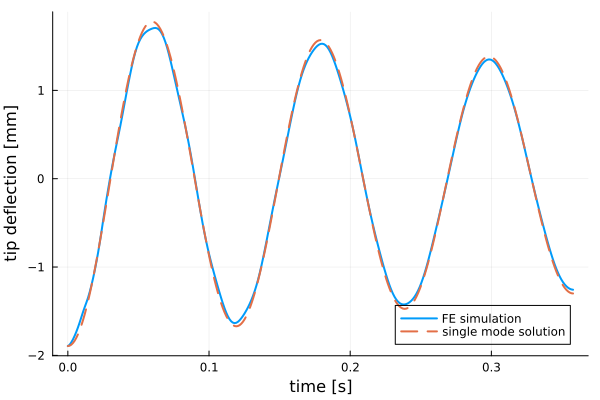

In [23]:
function plot_tip_deflection(foreground_color)
    plt = Plots.plot(
        ts, u_tip .* 1.0e3; label = "FE simulation", lw = 2,
        xlabel = "time [s]", ylabel = "tip deflection [mm]",
        background_color = :transparent, foreground_color = foreground_color,
    )
    Plots.plot!(plt, ts, u_sdof .* 1.0e3; label = "single mode solution", ls = :dash, lw = 2)
    return plt
end
plt = plot_tip_deflection(:black)

![](elastodynamics_tip-light.svg)
![](elastodynamics_tip-dark.svg)

*Figure 3*: Tip deflection history from the finite element simulation compared with the
analytical single mode solution.

The finite element solution follows the envelope and frequency of the single mode
solution closely; the small wiggles on top of the smooth curve are the (weakly excited
and more strongly damped) higher modes. Note that, since $\omega_1$ itself comes from
the finite element model, this is a consistency check of the time integration rather
than an independent verification — the independent anchors against beam theory are the
natural frequencies and the static tip deflection compared above.

## Suggestions for tweaking the program
- Compute more modes and find the first *torsional* mode. Compare with the analytical
  frequency $f = \frac{1}{4L}\sqrt{G J / (\rho I_\mathrm{p})}$ for a clamped-free shaft.
- Replace the consistent mass matrix with a *lumped* (diagonal) one, e.g. by row-summing,
  and compare the natural frequencies. Lumped mass matrices underestimate frequencies
  while consistent ones overestimate.
- Set $\beta_\mathrm{N} = 0$, $\gamma_\mathrm{N} = 1/2$ (central difference) and observe
  what happens to the solution when the time step exceeds the stability limit
  $\Delta t_\mathrm{crit} = 2 / \omega_\mathrm{max}$.

In [24]:
using Test                                                     #hide
@test freqs ≈ f_analytical rtol = 0.03                         #hide
@test δ_tip ≈ δ_beam rtol = 0.03                               #hide
@test u_tip ≈ u_sdof rtol = 0.06                               #hide
nothing                                                        #hide

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*